# Actual EFA component I(q): WT and AA
This notebook generates the **component-level scattering curves**, rather than presenting a selected-frame average as an EFA result. Start with the two `*_EFA_candidate_main.dat` files and `component_Iq_comparison.png`.

The question is whether contaminating larger material could inflate AA's apparent size. We do not assume that an extra fitted component is a clean oligomer, or that the main fitted component has been proven monomeric. A two-component calculation is tested as a hypothesis; it is not a selected biological species count.

The existing notebooks 01–03 remain prior-method/reproduction references. This notebook uses an independently assessed residual-background hypothesis and does **not** redo the unavailable original facility solvent subtraction.

**Provenance correction (22 September):** Natalie’s notebooks perform buffer subtraction on the HDF5 input profiles. Both AA_082024.ipynb and AA_052026.ipynb load AA_052026.hdf5 and report buffer frames24–70; the primary WT analysis reports220–236. Earlier claims that the needed pre-subtraction profiles were absent, or that our HDF5-based subtraction was necessarily only a residual correction, were incorrect. The HDF5-based calculations already read `profiles` and subtract their chosen buffer once, so this correction does not itself change their numerical output. Original exported DAT curves are a later processing stage and must not be subtracted again. The new controlled test is in [09_buffer_window_sensitivity.ipynb](09_buffer_window_sensitivity.ipynb).

In [1]:
from pathlib import Path
import sys, json, numpy as np
from IPython.display import display, Image, Markdown
ROOT=Path.cwd();sys.path.insert(0,str(ROOT/'analysis'))
from component_recovery import *
from audit_component_recovery import audit, validate
from component_anchor_sensitivity import anchors_audit
from component_bift_controls import controls
from plot_component_recovery import make_plots


## Baseline assumptions and uncertainty
The working baseline is a q-dependent linear interpolation between residual-background anchor means. WT anchors are **55–94 and 210–234**; AA anchors **35–74 and 225–254**. These are independently assessed intervals, not a claim of known analyte-free blanks. WT's post region is moved beyond the EFA fit interval to avoid fitting its tail directly. AA 230–259 was rejected because its mid/high-q drift failed the stationarity screen. All bounds are zero indexed and inclusive.

We compare pre-only and post-only corrections as stress tests, and shift anchors by ±5 frames, rejecting intervals that fail the same stationarity screen. The interpolated model is a working hypothesis, **not a uniquely established optimal baseline**. The provisional custom integral correction is not used here.

Write the corrected matrix as $D=YA$, where each column of $A$ selects a frame and subtracts the appropriate weighted anchor averages. For a component extraction vector $l_k$, $s_k=YAl_k$, so its fixed-elution variance is
$$\mathrm{Var}(s_{ik}\mid C)=\sum_j \sigma_{ij}^2(Al_k)_j^2.$$
This includes the shared residual-background covariance, including overlapping frame/anchor effects. Unknown correlations introduced by the facility's original subtraction remain unavailable.

In [2]:
checks, anchor_results=anchors_audit()
assert all(r['passes'] for r in checks)
for r in checks: print(r)
print('Synthetic recovery / covariance checks:', validate())
(ROOT/'component_results/validation.json').write_text(json.dumps(validate(),indent=2));


{'sample': 'WT_092025', 'side': 'pre', 'start': 55, 'end': 94, 'n': 40, 'max_band_slope_z': 2.9658017405921675, 'band_slope_z': [-1.0475688221496708, -1.438039032351882, -0.6949304153192662, -2.9658017405921675], 'half_profile_ms': 0.5872888697114206, 'passes': True}
{'sample': 'WT_092025', 'side': 'post', 'start': 210, 'end': 234, 'n': 25, 'max_band_slope_z': 1.454359144317892, 'band_slope_z': [-1.454359144317892, -1.3914512691678056, 0.40462614553357545, -0.8910031805556414], 'half_profile_ms': 0.708127457173919, 'passes': True}
{'sample': 'AA_052026', 'side': 'pre', 'start': 35, 'end': 74, 'n': 40, 'max_band_slope_z': 1.5448546019610467, 'band_slope_z': [-0.5177956333592204, 1.0194571788533608, 1.5448546019610467, 0.5883188619336097], 'half_profile_ms': 0.551774915929892, 'passes': True}
{'sample': 'AA_052026', 'side': 'post', 'start': 225, 'end': 254, 'n': 30, 'max_band_slope_z': 1.2017320410466052, 'band_slope_z': [-0.8601749391437581, -1.2017320410466052, -1.002604083923927, -1.1

## Forward/backward EFA and actual curve recovery
The row-scaled matrix is $D_w=U\Sigma V^T$. Forward and backward SVD diagnose evolving signal rank; the support intervals then constrain a nonnegative elution rotation. For the resulting elution matrix $C$, the scattering curves are
$$S=D(C^T)^+.$$
We retain the original signed scattering values; **no smoothing or positivity clipping is applied to the recovered I(q)**. Elution coefficients are constrained nonnegative. Their normalization is arbitrary and is not a mole fraction.

Fiducial WT: frames 120–205, supports 120–175 and 140–205. Fiducial AA: frames 145–215, supports 145–185 and 160–215. These are explicit trial supports, not unique intervals established by EFA. The exported main candidate is the component with the second support, scaled to its contribution to the selected frame average. Other supports and q ranges are tested below.

In [3]:
import itertools
rows=[]
for name,spec in SPECS.items():
    for kind,end,start,qmax in itertools.product(['linear','pre','post'],spec['ends'],spec['starts'],[.15,.25]):
        r,_=evaluate(name,kind,end,start,qmax);rows.append(r)
    print(name, '72 baseline/support/q-range combinations evaluated')
(OUT/'rotation_grid.json').write_text(json.dumps(rows,indent=2));


WT_092025 72 baseline/support/q-range combinations evaluated


AA_052026 72 baseline/support/q-range combinations evaluated


## Refit the decomposition under noise; do not treat C as exact
Each sample gets 100 parametric perturbations of all 450 original frame profiles, followed by the same residual-background transform and a fresh EFA rotation. The DAT uncertainty column is the standard deviation of these recovered curves. Bootstrap intervals remain conditional on this baseline, component count and supports.

A separate 200-replicate rank-one null simulation tests whether the second singular value exceeds what the supplied errors and the new shared baseline could produce. It tests an additional signal pattern, **not oligomer identity**. Error calibration and unmodelled background structure can affect this test.

In [4]:
results={name:audit(name,bootstrap=100,null_reps=200) for name in SPECS}
for name,r in results.items():
    print(name, 'average / candidate Rg:',r['average_guinier']['Rg'],r['candidate_guinier']['Rg'])
    print('Candidate bootstrap 95%:',r['bootstrap_Rg_95'])
    print('Paired candidate-minus-average Rg 95%:',r['bootstrap_delta_Rg_vs_average_95'])
    print('s2 / null 99%:',r['singular_values'][1],r['null_s2_99'])


AUDIT WT_092025 {"converged": true, "iterations": 64, "supports": [[120, 175], [140, 205]], "q": [0.012, 0.25], "singular_values": [803.949824582736, 56.95407586128936, 16.072371443428224, 15.665912320782057], "residual_ms": 0.8918972071039891, "rank1_residual_ms": 1.1268522374008356, "condition": 1.3109385520093002, "peaks": [140, 167], "negative_fraction": [0.0, 0.0], "sample": "WT_092025", "baseline": "linear", "main_guinier": {"Rg": 27.370632359474758, "se": 1.007956756938651, "I0": 41.799130829412334, "qmin": 0.012, "qmax": 0.030000000000000002, "qRgmax": 0.8211189707842428, "chi2": 0.5173544344560622}, "main_guinier_adaptive": {"Rg": 25.81724476236083, "fit_se": 0.4843973477915141, "I0": 41.222990182526495, "qmin": 0.012, "qmax": 0.038, "qRgmax": 0.9810553009697115, "n": 27, "chi2": 0.6565977796647288}, "strong_negative_fraction": [0.0, 0.0], "main_screen": true, "bootstrap_requested": 100, "bootstrap_converged": 100, "bootstrap_failed": 0, "bootstrap_Rg_95": [25.15163469267222, 

/Users/f0044gk/Desktop/SAXS/bioxtasraw-source/bioxtasraw/BIFT.py:334: RuntimeWarning: invalid value encountered in divide
  sinc_qr = np.where(qr==0, 1, np.sin(qr)/qr)


AUDIT AA_052026 {"converged": true, "iterations": 220, "supports": [[145, 185], [160, 215]], "q": [0.012, 0.25], "singular_values": [1687.5740212031023, 13.770117933886528, 13.5904898458204, 13.403871215487307], "residual_ms": 0.5703687102781724, "rank1_residual_ms": 0.5890299804687953, "condition": 3.4720581207955767, "peaks": [176, 177], "negative_fraction": [0.6236559139784946, 0.0], "sample": "AA_052026", "baseline": "linear", "main_guinier": {"Rg": 31.523532027540238, "se": 0.7235157875888595, "I0": 127.59615311630492, "qmin": 0.012, "qmax": 0.030000000000000002, "qRgmax": 0.9457059608262072, "chi2": 1.0725437131810263}, "main_guinier_adaptive": {"Rg": 31.197790356785916, "fit_se": 0.5746897662515636, "I0": 127.20190400780766, "qmin": 0.012, "qmax": 0.032, "qRgmax": 0.9983292914171493, "n": 21, "chi2": 1.2396283912995418}, "strong_negative_fraction": [0.010752688172043012, 0.0], "main_screen": true, "bootstrap_requested": 100, "bootstrap_converged": 100, "bootstrap_failed": 0, "bo

WT_092025 average / candidate Rg: 28.59708418784204 27.419216187910862
Candidate bootstrap 95%: [25.15163469267222, 29.28921277264585]
Paired candidate-minus-average Rg 95%: [-2.320230203709487, -0.2632571278960657]
s2 / null 99%: 56.95407586128936 19.268498166748515
AA_052026 average / candidate Rg: 32.15099844078291 31.800395069738123
Candidate bootstrap 95%: [30.33010142115153, 33.28262072911953]
Paired candidate-minus-average Rg 95%: [-1.5025164101767494, 0.8706754488056824]
s2 / null 99%: 13.770117933886528 18.7732355590244


### I(q) first, with conventional and extended Guinier side by side
These executable comparisons use the same exported curves and propagated errors. Fit ranges and conditional uncertainties are shown explicitly. The additional matched-range extended column separates model-form effects from q-range effects. See notebook07 for paired differences and full uncertainty assumptions.

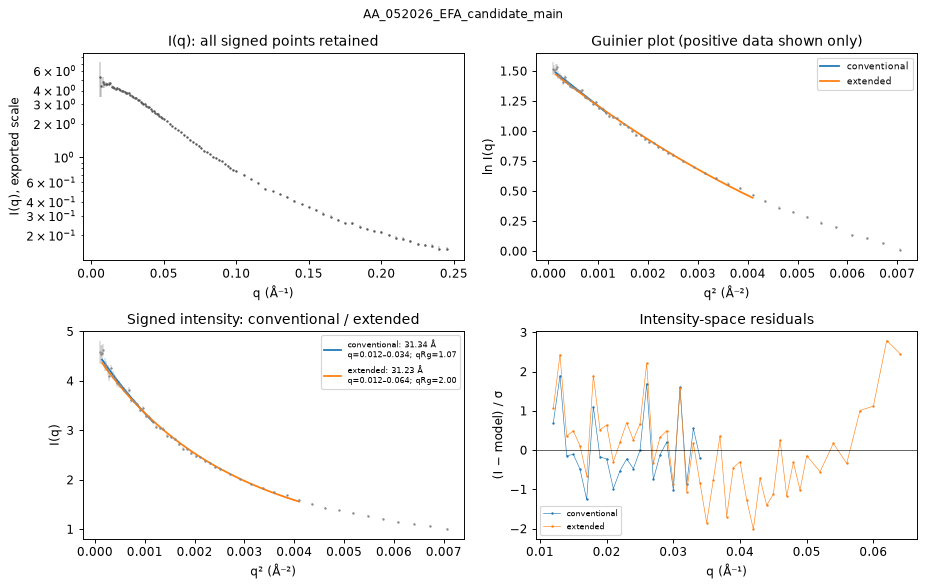

Component identity and physical validity are not established by a converged fit.

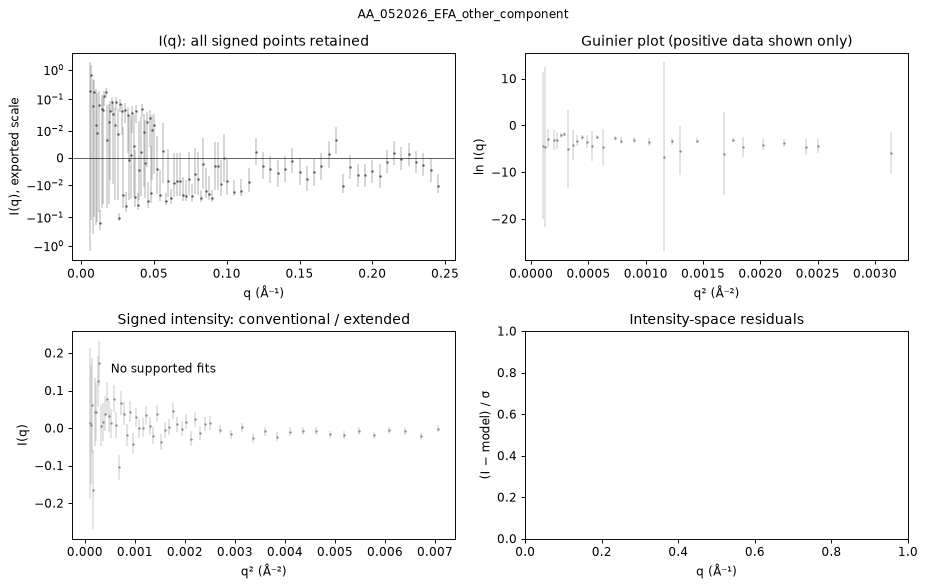

Component identity and physical validity are not established by a converged fit. No supported extended fit; do not interpret as a species Rg.

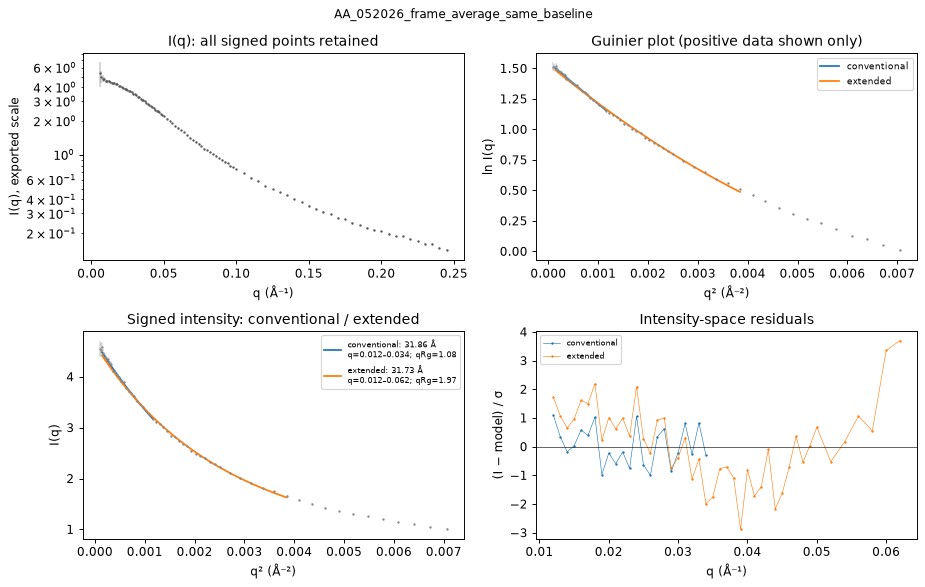

Component identity and physical validity are not established by a converged fit.

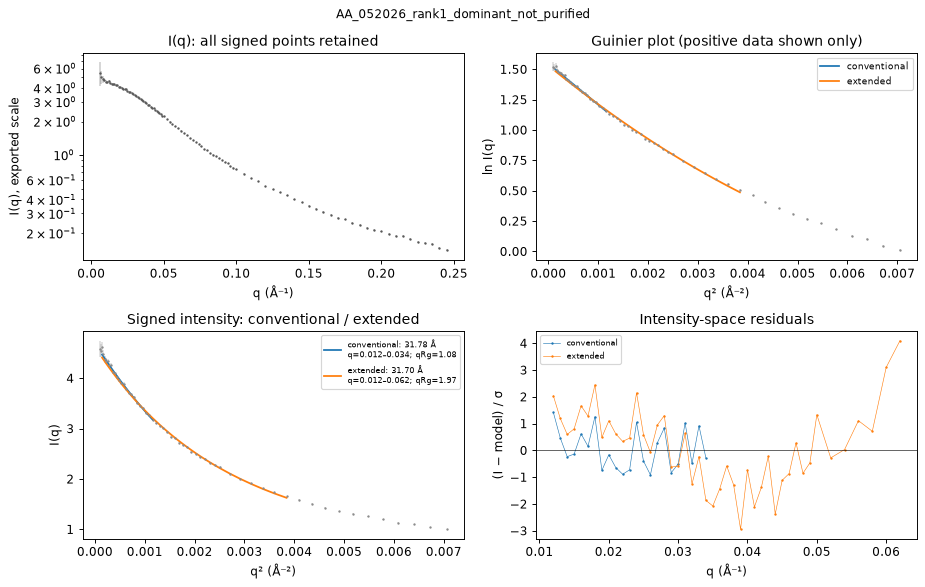

Component identity and physical validity are not established by a converged fit. Extended residual chi-square/dof >2.

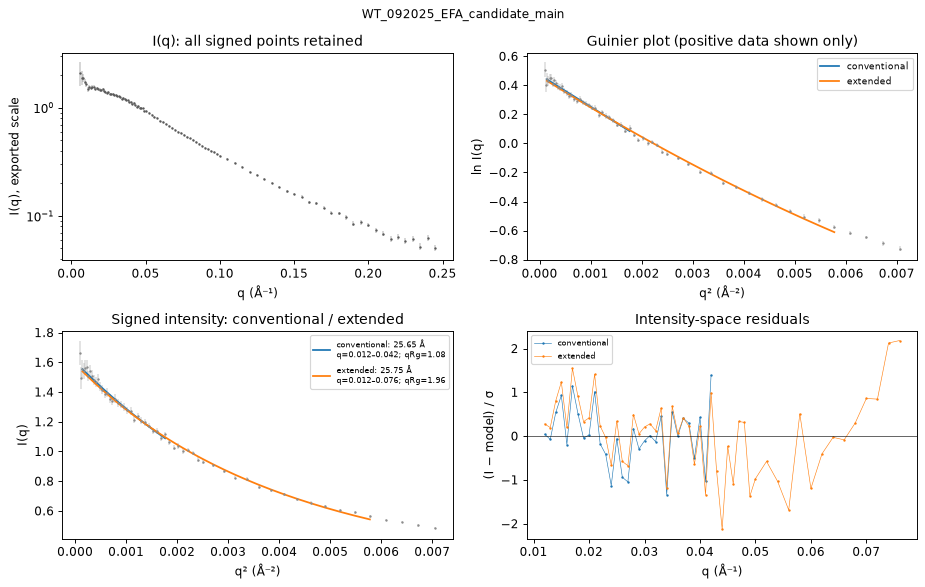

Component identity and physical validity are not established by a converged fit.

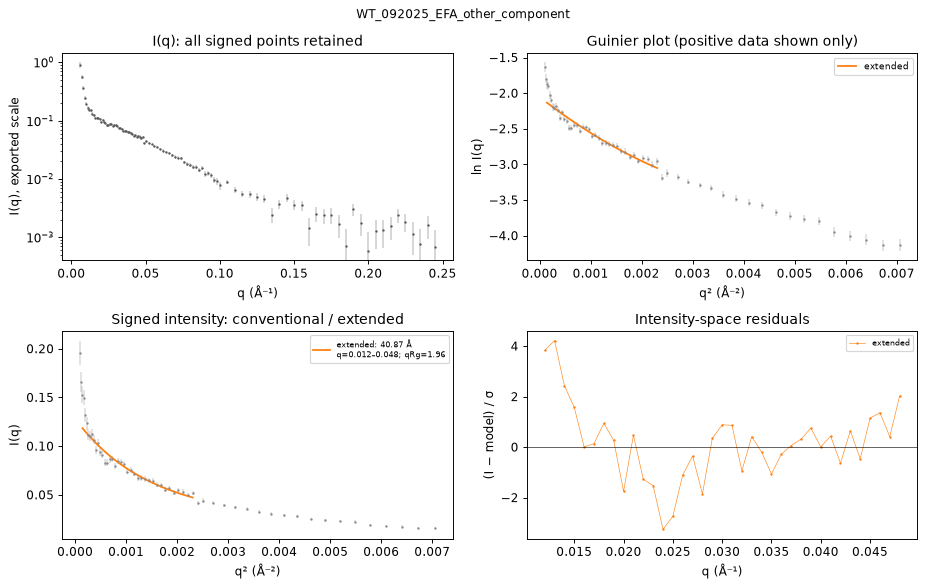

Component identity and physical validity are not established by a converged fit. Extended residual chi-square/dof >2.

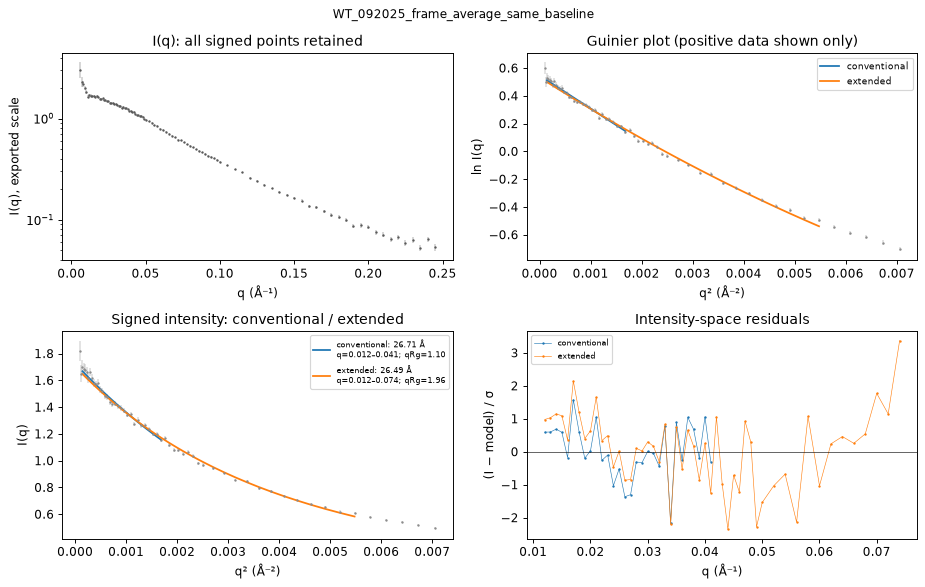

Component identity and physical validity are not established by a converged fit.

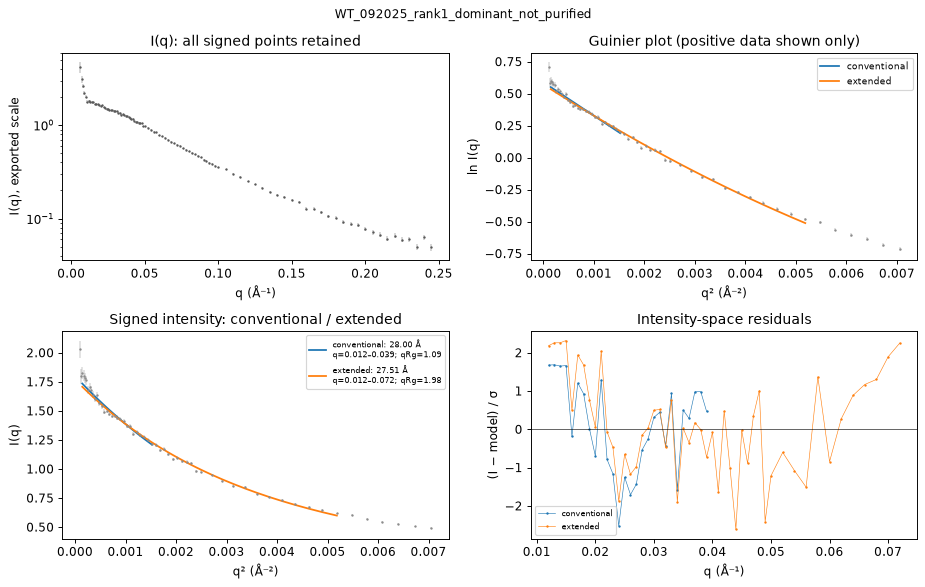

Component identity and physical validity are not established by a converged fit.

| Curve | Conventional Rg ± SE (Å) | Extended, same q range | Extended, qRg≤2 | Conditional extended 95% |
|---|---:|---:|---:|---|
|AA_052026_EFA_candidate_main|31.34 ± 0.52|32.55 ± 0.61|31.23 ± 0.15|[31.03, 31.72]|
|AA_052026_EFA_other_component|unsupported|unsupported|unsupported|unsupported|
|AA_052026_frame_average_same_baseline|31.86 ± 0.29|33.18 ± 0.34|31.73 ± 0.09|[31.57, 31.87]|
|AA_052026_rank1_dominant_not_purified|31.78 ± 0.28|33.09 ± 0.33|31.70 ± 0.08|[31.53, 31.86]|
|WT_092025_EFA_candidate_main|25.65 ± 0.44|26.44 ± 0.50|25.75 ± 0.15|[25.38, 26.04]|
|WT_092025_EFA_other_component|unsupported|unsupported|40.87 ± 0.88|[39.15, 42.86]|
|WT_092025_frame_average_same_baseline|26.71 ± 0.37|27.60 ± 0.42|26.49 ± 0.12|[26.27, 26.78]|
|WT_092025_rank1_dominant_not_purified|28.00 ± 0.39|28.98 ± 0.45|27.51 ± 0.13|[27.26, 27.74]|


In [1]:
from pathlib import Path
import sys,json,numpy as np
from IPython.display import display,Markdown
ROOT=Path.cwd()
if not (ROOT/'analysis/compare_all_iq.py').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from compare_all_iq import *
%matplotlib inline

_all=json.loads((OUT/'fit_results.json').read_text())
comparison_rows=gallery(_all,['Audited EFA and matched average'])

## Separate P(r) curve changes from regularization/error changes
BIFT estimates P(r) for the candidate and the frame average. Decomposition changes both I(q) and its uncertainties, which can change regularization and Dmax even without a corresponding structural change. Therefore we also fit the **unchanged average using candidate errors**, and the candidate using average errors. The latter is a diagnostic control, not its proper uncertainty model.

BIFT here uses diagonal uncertainties and cannot account for the full q covariance induced by decomposition. Its reported errors do not describe all model ambiguity. In particular, a shortened AA P(r) tail cannot automatically be interpreted as removal of an oligomer.

[{'sample': 'WT_092025', 'control': 'average_matched_candidate_errors', 'Rg': 27.81686497747812, 'Dmax': 95.45724643803113, 'chi2': 0.8580257420650517}, {'sample': 'WT_092025', 'control': 'candidate_matched_average_errors', 'Rg': 27.066428878829104, 'Dmax': 92.07054626505867, 'chi2': 0.9697116725262149}, {'sample': 'AA_052026', 'control': 'average_matched_candidate_errors', 'Rg': 32.87028147555923, 'Dmax': 120.23717726890848, 'chi2': 0.3341430349849396}, {'sample': 'AA_052026', 'control': 'candidate_matched_average_errors', 'Rg': 33.68857891033146, 'Dmax': 148.5716316788062, 'chi2': 2.9596334058110427}]


[
  {
    "sample": "WT_092025",
    "control": "average_matched_candidate_errors",
    "Rg": 27.81686497747812,
    "Dmax": 95.45724643803113,
    "chi2": 0.8580257420650517
  },
  {
    "sample": "WT_092025",
    "control": "candidate_matched_average_errors",
    "Rg": 27.066428878829104,
    "Dmax": 92.07054626505867,
    "chi2": 0.9697116725262149
  },
  {
    "sample": "AA_052026",
    "control": "average_matched_candidate_errors",
    "Rg": 32.87028147555923,
    "Dmax": 120.23717726890848,
    "chi2": 0.3341430349849396
  },
  {
    "sample": "AA_052026",
    "control": "candidate_matched_average_errors",
    "Rg": 33.68857891033146,
    "Dmax": 148.5716316788062,
    "chi2": 2.9596334058110427
  }
]


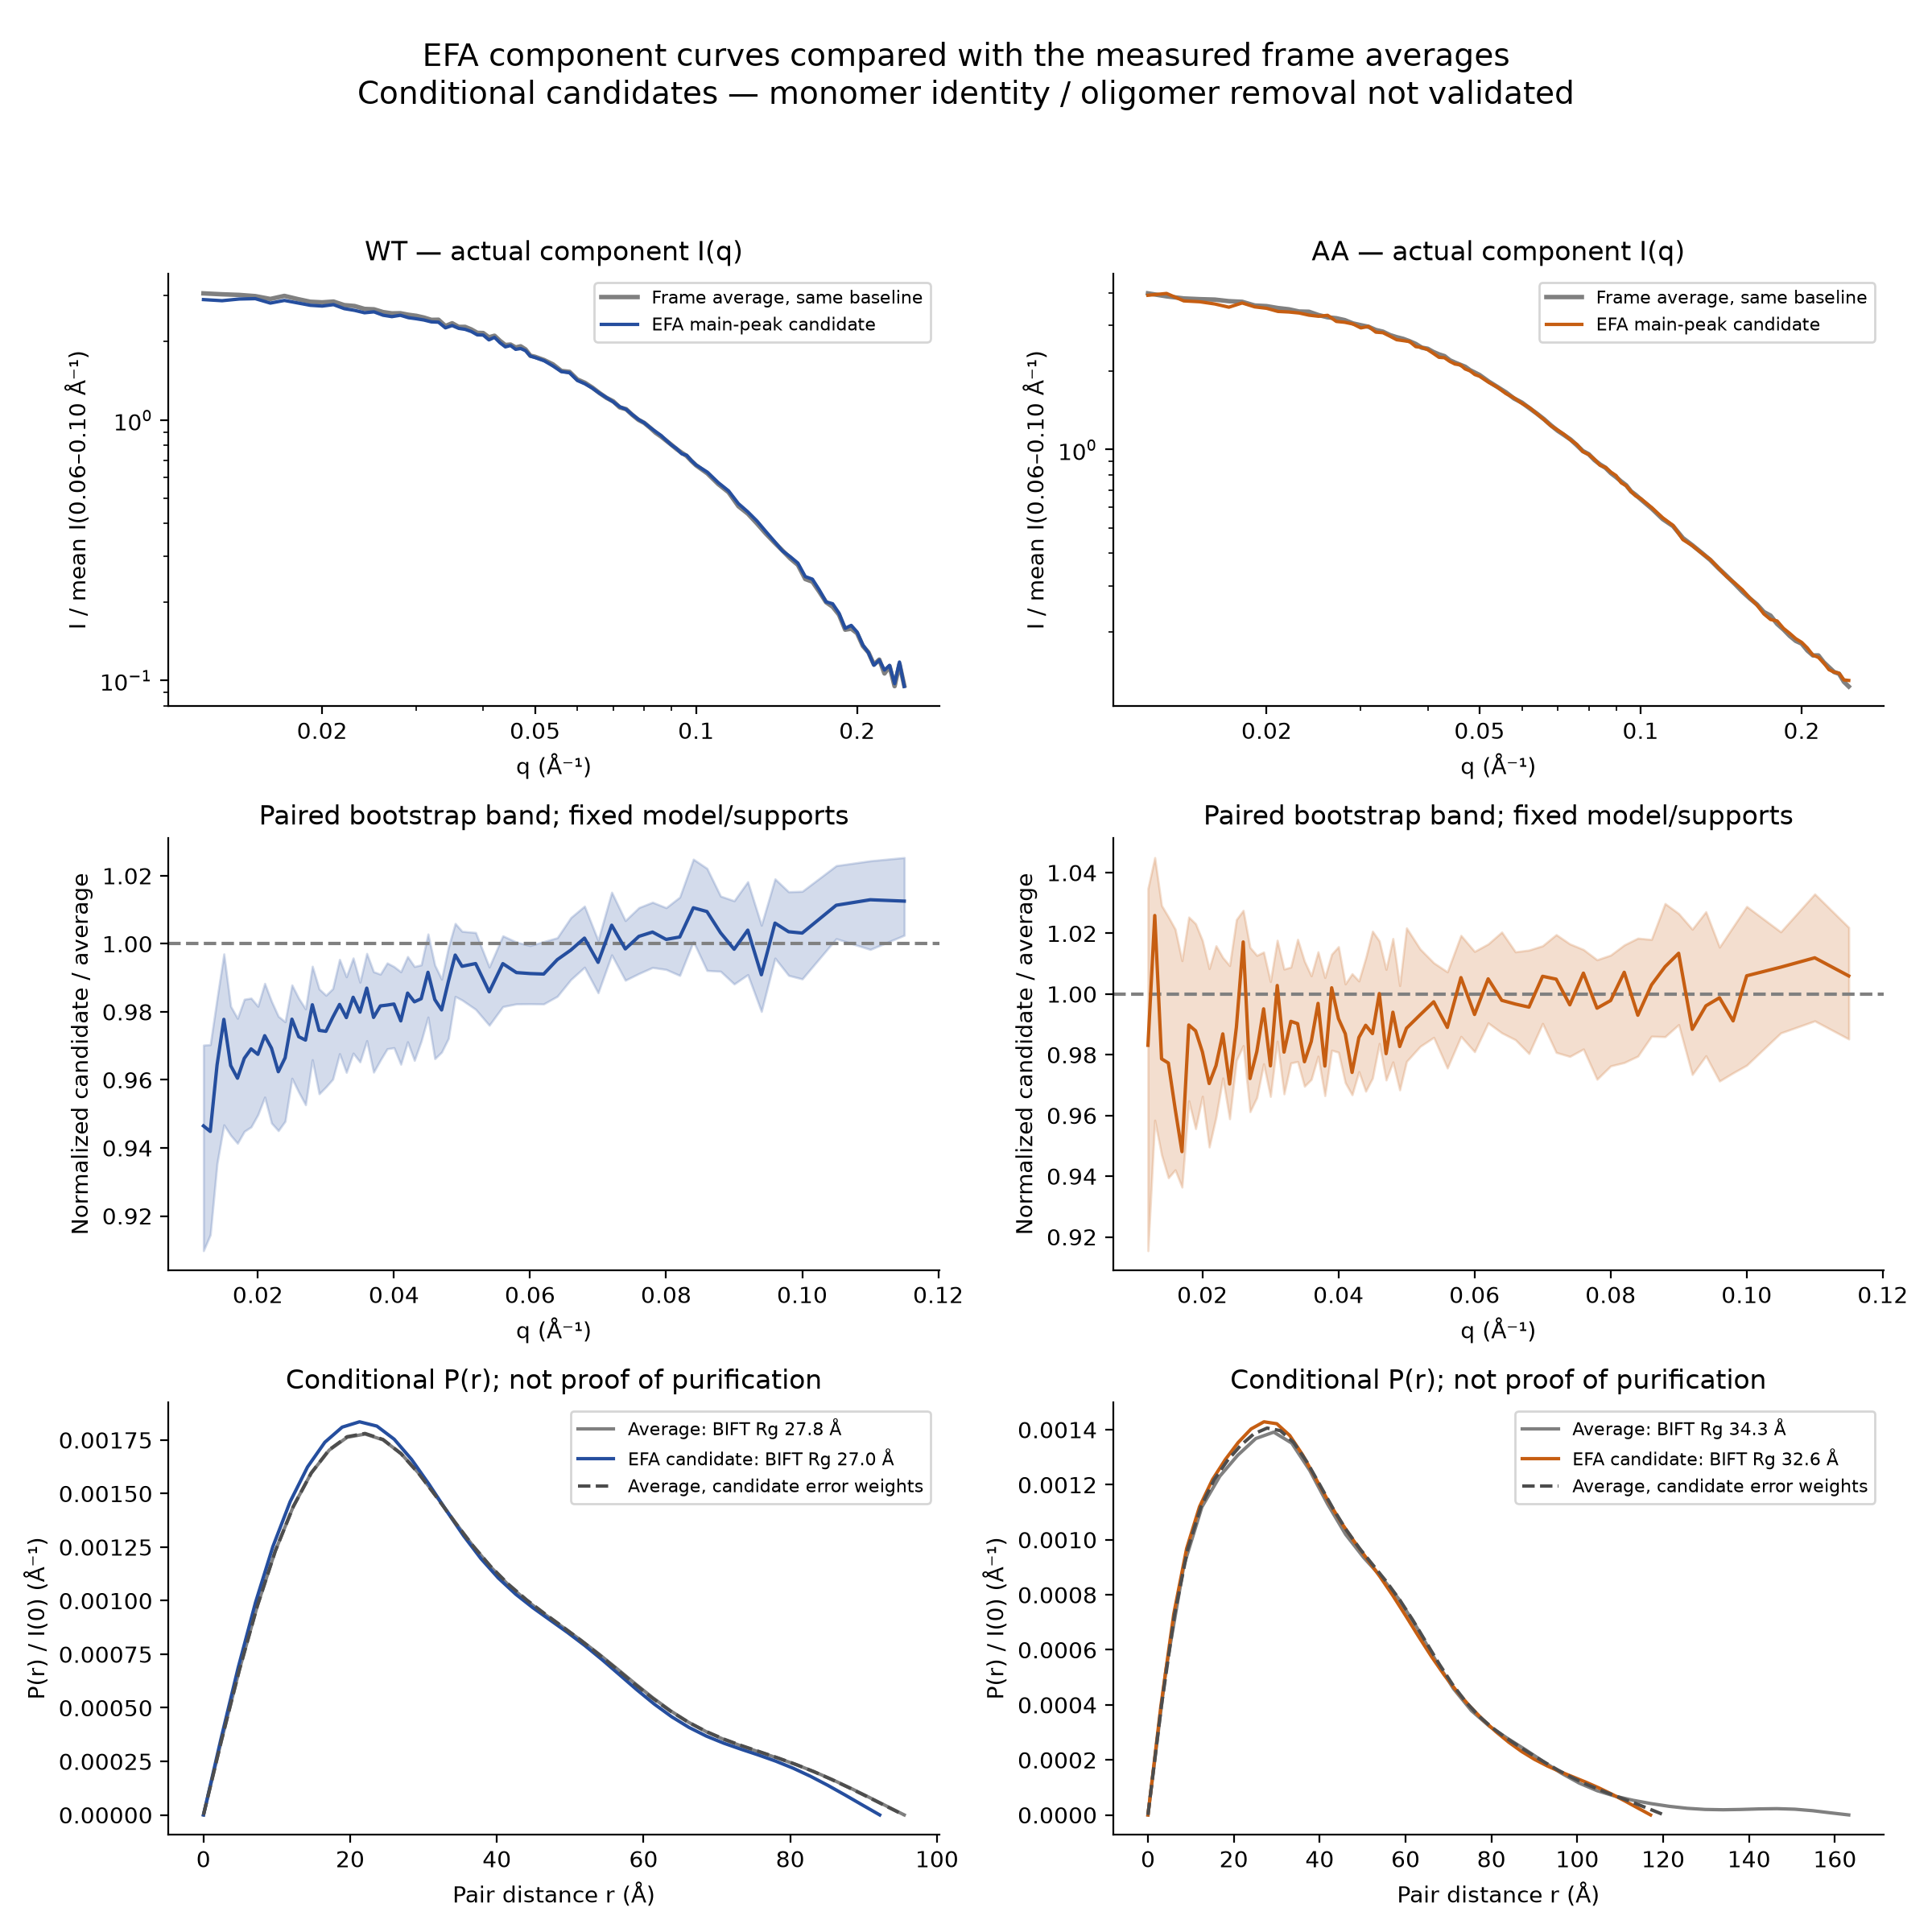

In [5]:
controls()
make_plots()
print((OUT/'bift_weight_controls.json').read_text())
display(Image(filename=str(OUT/'component_Iq_comparison.png')))


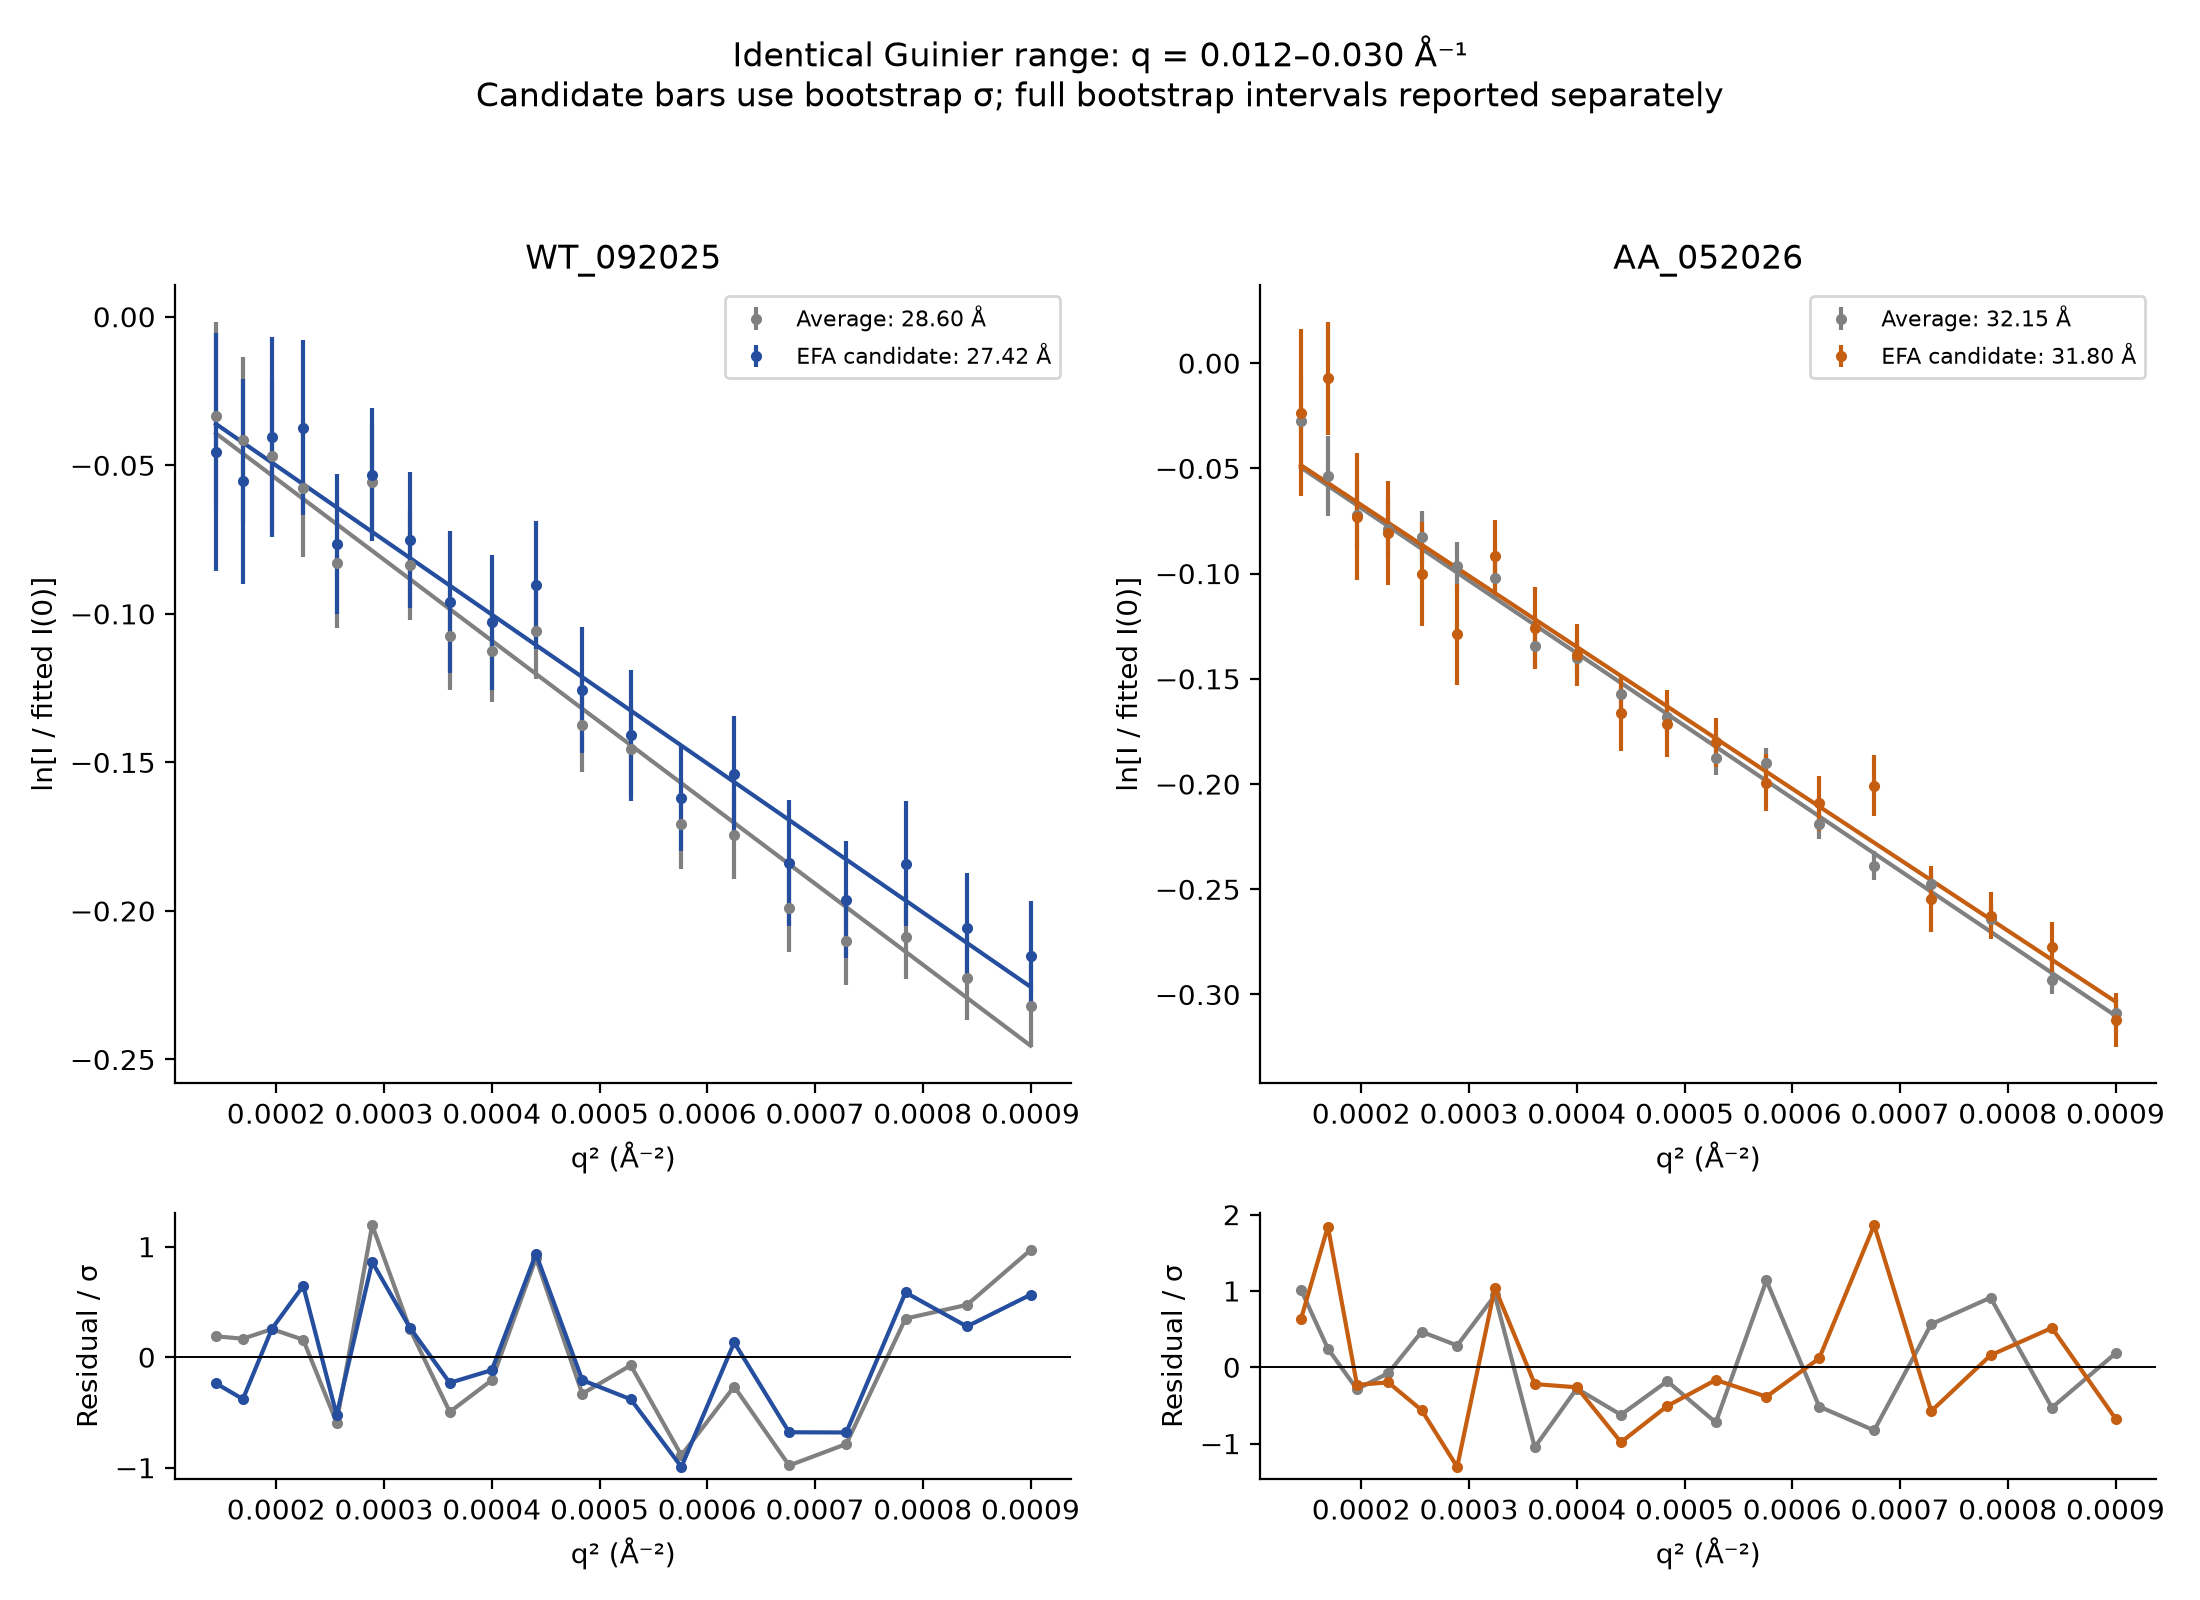

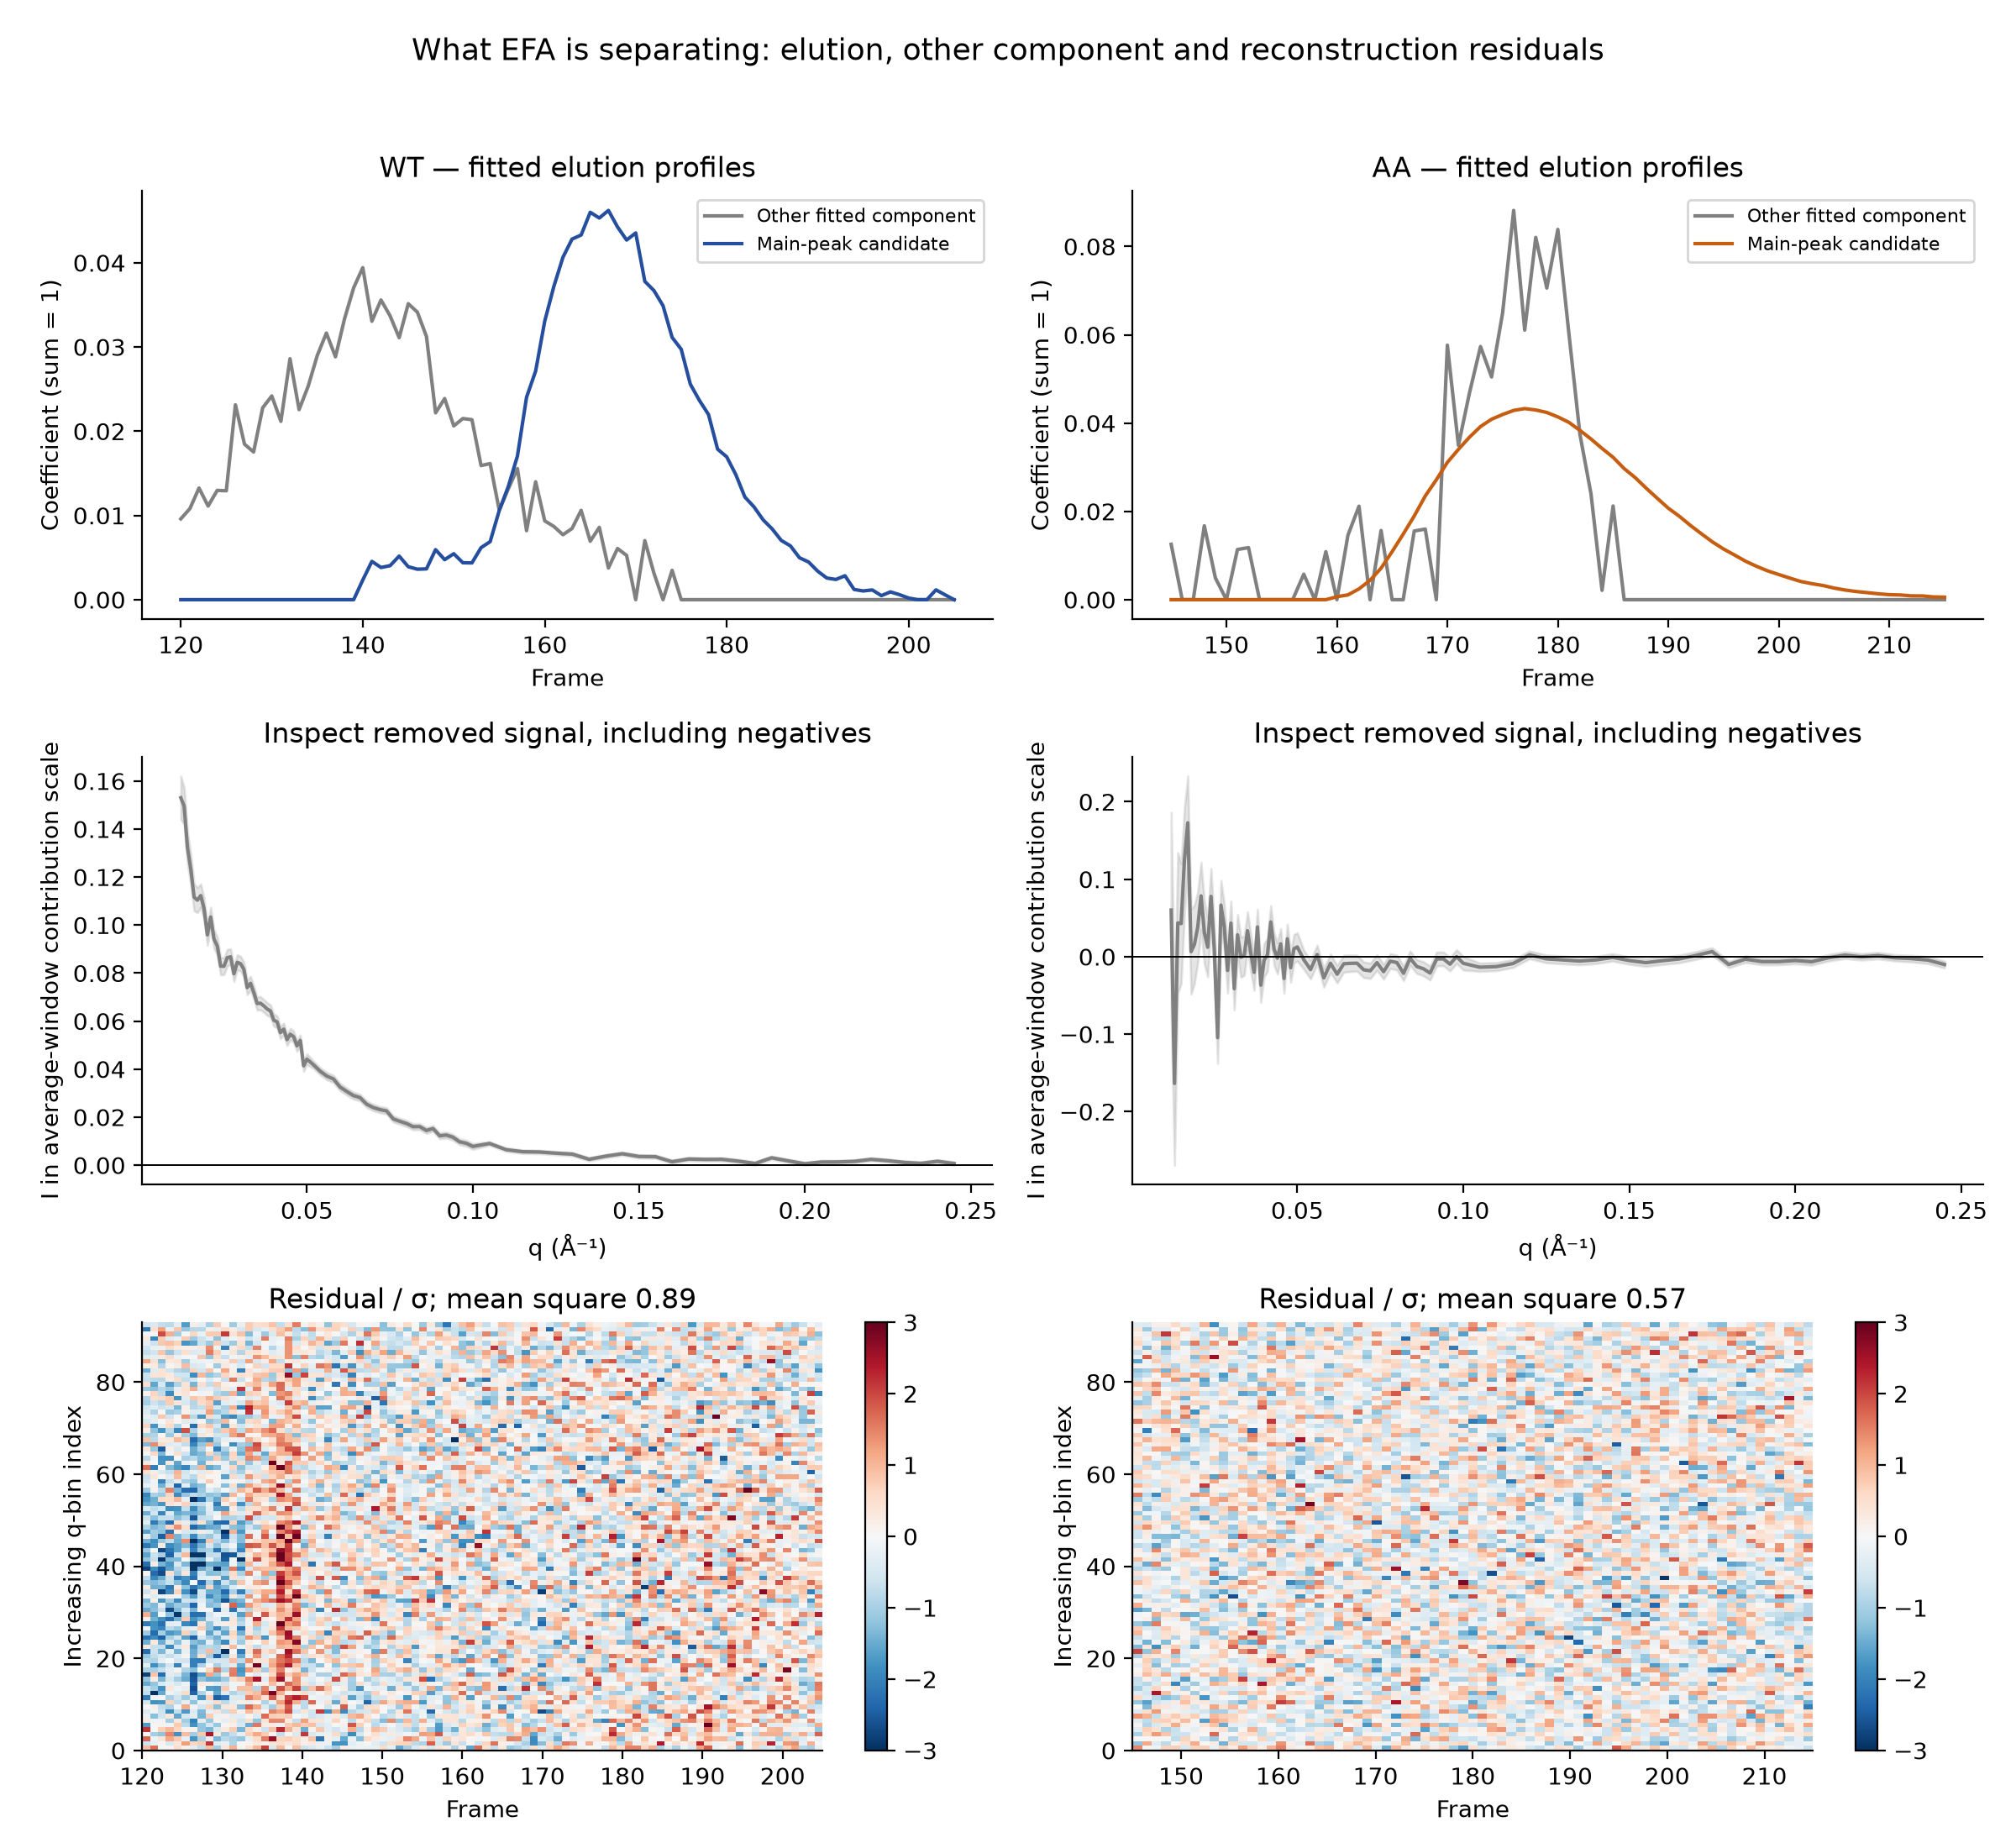

In [6]:
display(Image(filename=str(OUT/'component_Guinier.png')))
display(Image(filename=str(OUT/'decomposition_diagnostics.png')))


## Stability and the contamination question
The plotted sensitivity set includes converged rotations with condition number <30, no main-curve q bins below −3 conditional errors, a valid common-range Guinier slope, and residual mean square no worse than 1.1 times rank one. The candidate main peak must lie within 5 frames of the observed main peak; for WT, the other component must peak before frame 155 to represent the observed shoulder. These screens do **not** certify biological purity. AA's extra fitted curve remains largely noise/negative even when the main curve passes.

All Guinier comparisons below use exactly q=0.012–0.030 Å⁻¹. Differences from earlier reported values reflect both the changed baseline and the fit convention; compare within this notebook, not across methods without the audit.

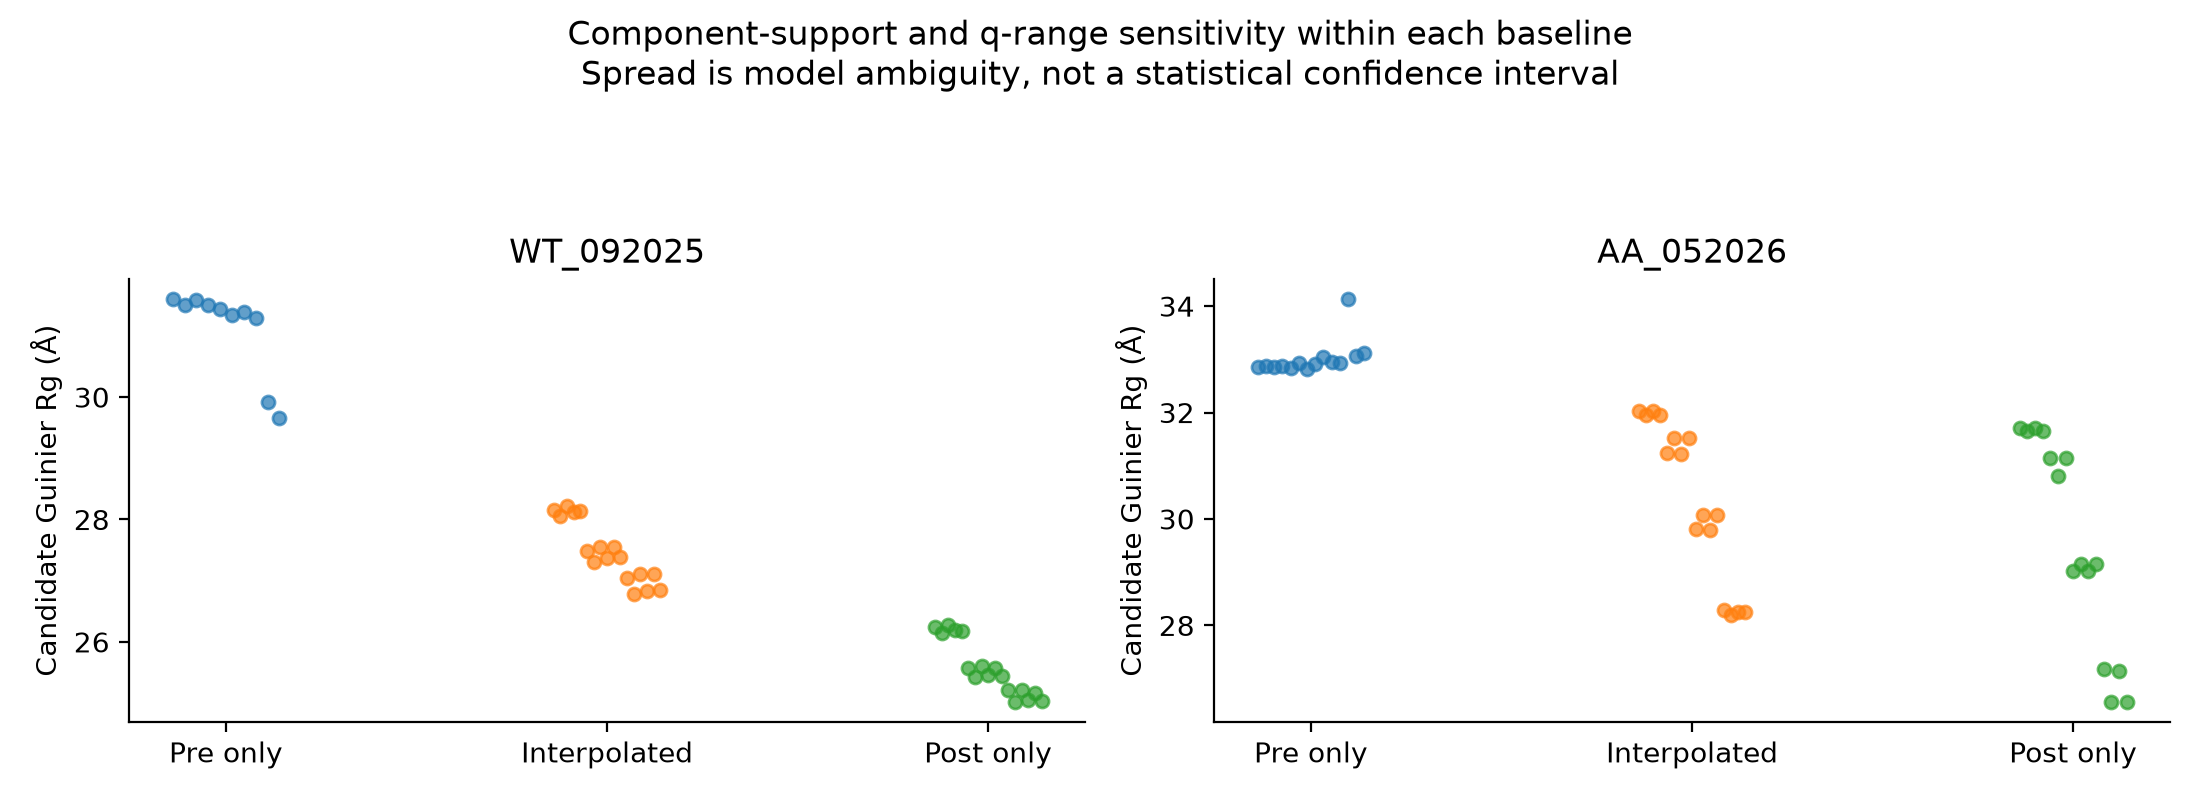

{
  "primary": [
    {
      "sample": "WT_092025",
      "average_Rg": 28.59708418784204,
      "candidate_Rg": 27.419216187910862,
      "bootstrap_Rg_95": [
        25.15163469267222,
        29.28921277264585
      ],
      "bootstrap_delta_95": [
        -2.320230203709487,
        -0.2632571278960657
      ],
      "s2": 56.95407586128936,
      "s2_null99": 19.268498166748515,
      "candidate_bift_Rg": 27.049332234261225
    },
    {
      "sample": "AA_052026",
      "average_Rg": 32.15099844078291,
      "candidate_Rg": 31.800395069738123,
      "bootstrap_Rg_95": [
        30.33010142115153,
        33.28262072911953
      ],
      "bootstrap_delta_95": [
        -1.5025164101767494,
        0.8706754488056824
      ],
      "s2": 13.770117933886528,
      "s2_null99": 18.7732355590244,
      "candidate_bift_Rg": 32.57050916372072
    }
  ],
  "sensitivity": [
    {
      "sample": "WT_092025",
      "baseline": "pre",
      "n": 10,
      "Rg_range": [
        29.6580173500

In [7]:
display(Image(filename=str(OUT/'component_model_sensitivity.png')))
print((OUT/'summary.json').read_text())
print('Leading / central / trailing direct-average check:')
for r in json.loads((OUT/'elution_window_check.json').read_text()):
    print(r['sample'],r['frames'],round(r['Rg'],2),'±',round(r['se'],2),'Å; qmaxRg',round(r['qRgmax'],3))


## What has and has not been obtained
- **WT:** an actual main-peak component curve with a distinguishable earlier pattern. Its low-q shape changes relative to the average, but its absolute size depends materially on the residual-background model. Neither component is assigned a molecular identity from this alone.
- **AA:** an actual candidate curve from the forced two-component hypothesis. Its second singular value is not resolved above the supplied-error null; the candidate-minus-average Guinier shift includes zero in the conditional bootstrap. Its decomposition is not established as successful removal of oligomer contamination.
- Across AA's peak, direct-average fixed-range Rg remains roughly 31–32 Å, with increasing uncertainty in the tail. This does not prove absence of co-eluting contaminants.
- **No validated purified monomer I(q) is claimed.** The requested component curves, removed-pattern curves, residuals, uncertainties and alternatives are now explicit. Additional raw buffer/sample data and/or independent mass evidence are needed to settle the remaining interpretation.

The component DAT files contain q, intensity and conditional bootstrap sigma. Their arbitrary intensity scale is the component's contribution to the selected mean, not absolute concentration. A separate rank-one curve is exported and explicitly labelled **not purified**. The paired-bootstrap comparison and baseline/support spread are more informative than a single smooth-looking curve.

## Kratky comparisons
Raw: q²I(q) versus q. I(0)-normalized: q²I(q)/I(0) versus q. Dimensionless: (qRg)²I(q)/I(0) versus qRg. Conventional and extended Guinier normalizations are shown separately; extended curves use the measured I(q), not an extrapolation of the extended Guinier model to high q.

Raw component scales can differ. Multiplication by q² amplifies high-q noise and residual backgrounds; apparent differences there are not automatically structural. Dimensionless normalization can hide absolute size differences, so read these alongside the Rg comparison. Kratky shape does not determine oligomer identity. [RAW Kratky documentation](https://bioxtas-raw.readthedocs.io/en/v2.3.1/tutorial/s1_kratky.html).

Pointwise95% bands: each intensity perturbation refits both Rg and I(0), preserving their dependence on that same curve. Interpolation at fixed qRg includes uncertainty in horizontal scaling; no extrapolation and no band where fewer than80% of draws cover the grid. Existing EFA perturbations are reused for main/average. Other curves assume independent q errors. These are conditional bands, not simultaneous confidence regions or tests of differences between correlated curves; baseline, support and fit-range choices remain additional uncertainty. Raw bands use±1.96q²sigma. Unsupported normalizations are explicitly omitted, while their signed raw Kratky curves remain visible.


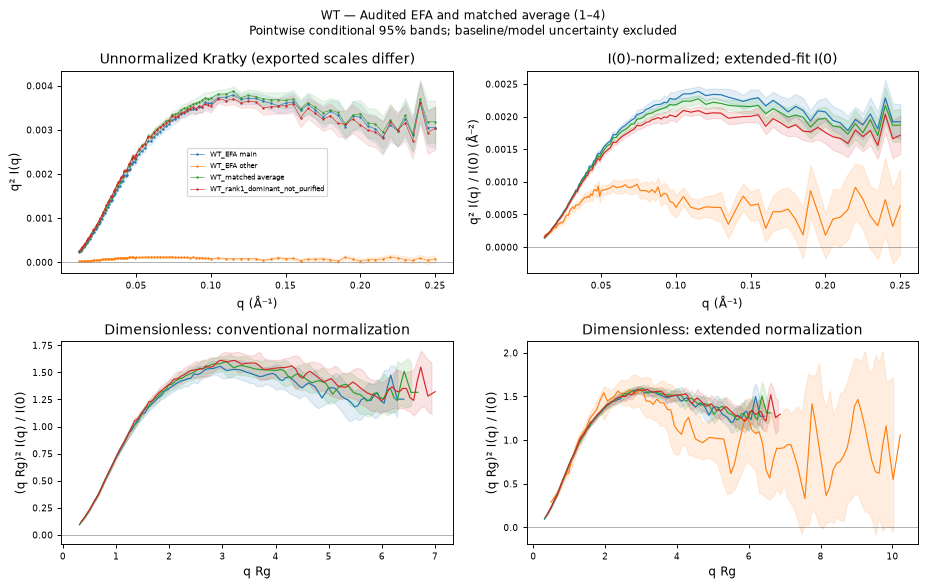

Unsupported normalization omitted: WT_EFA other / conventional

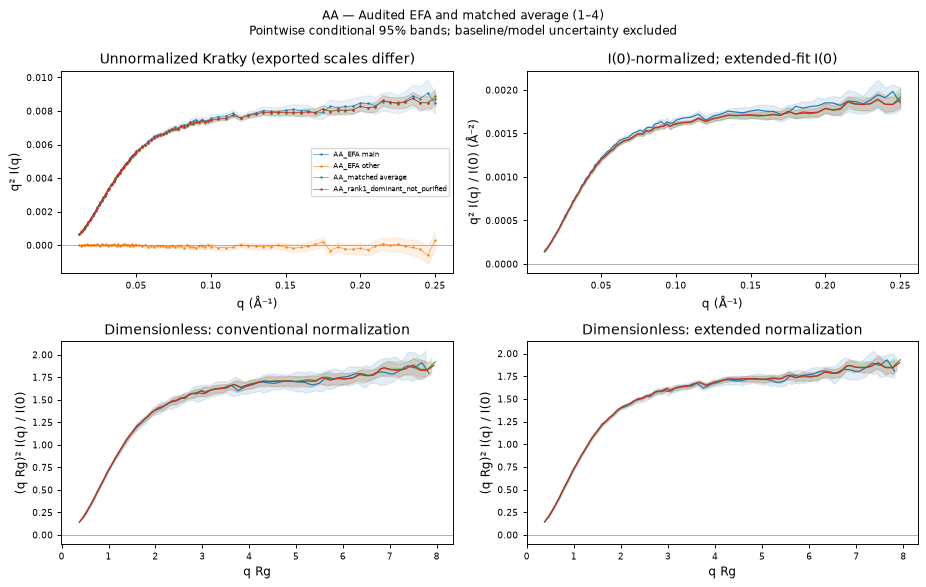

Unsupported normalization omitted: AA_EFA other / conventional; AA_EFA other / extended

In [1]:
from pathlib import Path
import sys,json
ROOT=Path.cwd()
if not (ROOT/'analysis/kratky_comparison.py').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from kratky_comparison import *
%matplotlib inline

if not (KOUT/'metadata.json').exists(): build_kratky_cache(n=200)
kratky_groups(['Audited EFA and matched average'])